In [ ]:
!pip install -q giotto-tda

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.6/554.6 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.8/455.8 kB 11.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from gtda.homology import VietorisRipsPersistence
from scipy.stats import wasserstein_distance
from sklearn.preprocessing import StandardScaler

# Función para cargar datos, calcular el diagrama de persistencia y devolver el diagrama
def calculate_persistence_diagram(file_path, dist_column):
    df = pd.read_csv(file_path)

    # Dividir los valores de la columna de distancia por 1000
    df[dist_column] = df[dist_column] / 1000

    # Incluimos 'crime_lon', 'crime_lat' y la columna de distancias en los datos
    data = df[['crime_lon', 'crime_lat', dist_column]].dropna().values  # Eliminar filas con NaN
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)

    VR = VietorisRipsPersistence()
    diagrams = VR.fit_transform([data_scaled])

    return diagrams[0]  # Diagrama de persistencia para el primer dataset

# Función para calcular la distancia de Wasserstein entre dos diagramas
def wasserstein_distance_between_diagrams(diag1, diag2):
    # Extraer las coordenadas de nacimiento y muerte
    births1, deaths1 = diag1[:, 0], diag1[:, 1]
    births2, deaths2 = diag2[:, 0], diag2[:, 1]

    # Asegúrate de que ambos diagramas tengan el mismo tamaño
    max_len = max(len(births1), len(births2))
    births1 = np.pad(births1, (0, max_len - len(births1)), constant_values=np.nan)
    deaths1 = np.pad(deaths1, (0, max_len - len(deaths1)), constant_values=np.nan)
    births2 = np.pad(births2, (0, max_len - len(births2)), constant_values=np.nan)
    deaths2 = np.pad(deaths2, (0, max_len - len(deaths2)), constant_values=np.nan)

    # Calcular la distancia de Wasserstein para las coordenadas de nacimiento y muerte
    distance_births = wasserstein_distance(births1[~np.isnan(births1)], births2[~np.isnan(births2)])
    distance_deaths = wasserstein_distance(deaths1[~np.isnan(deaths1)], deaths2[~np.isnan(deaths2)])

    # Combinar las distancias (puedes ajustar este paso si es necesario)
    return distance_births + distance_deaths

# Lista de distancias
dist = ['atm_dist', 'bank_dist', 'bar_dist', 'cafe_dist', 'industrial_dist',
        'market_dist', 'nightclub_dist', 'police_dist', 'pub_dist',
        'restaurant_dist', 'taxi_dist']

#HEADCHECK
# Archivo CSV
file_path = 'Valencia_2015_Sustraccion.csv'

# Calcular diagramas de persistencia para cada columna de distancias
diagrams = {}
for d in dist:
    diagrams[d] = calculate_persistence_diagram(file_path, d)

# Calcular distancias de Wasserstein entre los diagramas usando las distancias
dist_matrix = np.zeros((len(dist), len(dist)))

for i in range(len(dist)):
    for j in range(i + 1, len(dist)):
        dist_val = wasserstein_distance_between_diagrams(diagrams[dist[i]], diagrams[dist[j]])
        dist_matrix[i, j] = dist_val
        dist_matrix[j, i] = dist_val

# Mostrar la matriz de distancias
print("Matriz de distancias de Wasserstein entre diagramas de persistencia:")
print(dist_matrix)

Matriz de distancias de Wasserstein entre diagramas de persistencia:
[[0.         0.07002944 0.02272962 0.01931548 0.00499747 0.0144876
  0.00826954 0.00757142 0.02148151 0.06944585 0.01994188]
 [0.07002944 0.         0.04788183 0.05088087 0.07012476 0.08343557
  0.07437342 0.07534222 0.04955979 0.01223978 0.05060787]
 [0.02272962 0.04788183 0.         0.00777775 0.02354118 0.03614891
  0.02730386 0.02789958 0.00789613 0.04733538 0.00611245]
 [0.01931548 0.05088087 0.00777775 0.         0.02045234 0.03315226
  0.02387548 0.02562247 0.00655038 0.05033692 0.00868008]
 [0.00499747 0.07012476 0.02354118 0.02045234 0.         0.01337095
  0.00864093 0.00733387 0.02210456 0.06953172 0.02056657]
 [0.0144876  0.08343557 0.03614891 0.03315226 0.01337095 0.
  0.01033707 0.00980314 0.03454492 0.08282223 0.0332253 ]
 [0.00826954 0.07437342 0.02730386 0.02387548 0.00864093 0.01033707
  0.         0.0063911  0.02618356 0.07381759 0.02418263]
 [0.00757142 0.07534222 0.02789958 0.02562247 0.00733387 0

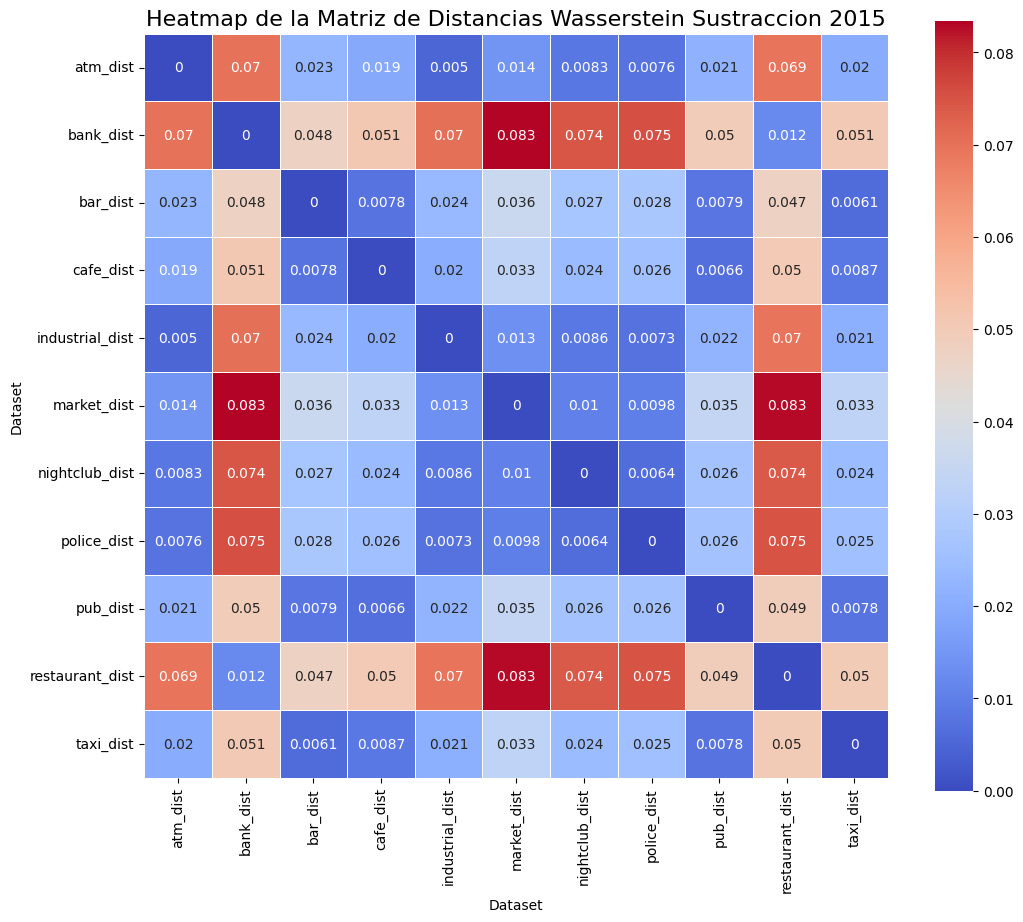

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Nueva matriz de distancias Wasserstein
dist_matrix_wasserstein = np.array([
    [0.        , 0.07002944, 0.02272962, 0.01931548, 0.00499747, 0.0144876 ,
     0.00826954, 0.00757142, 0.02148151, 0.06944585, 0.01994188],
    [0.07002944, 0.        , 0.04788183, 0.05088087, 0.07012476, 0.08343557,
     0.07437342, 0.07534222, 0.04955979, 0.01223978, 0.05060787],
    [0.02272962, 0.04788183, 0.        , 0.00777775, 0.02354118, 0.03614891,
     0.02730386, 0.02789958, 0.00789613, 0.04733538, 0.00611245],
    [0.01931548, 0.05088087, 0.00777775, 0.        , 0.02045234, 0.03315226,
     0.02387548, 0.02562247, 0.00655038, 0.05033692, 0.00868008],
    [0.00499747, 0.07012476, 0.02354118, 0.02045234, 0.        , 0.01337095,
     0.00864093, 0.00733387, 0.02210456, 0.06953172, 0.02056657],
    [0.0144876 , 0.08343557, 0.03614891, 0.03315226, 0.01337095, 0.        ,
     0.01033707, 0.00980314, 0.03454492, 0.08282223, 0.0332253 ],
    [0.00826954, 0.07437342, 0.02730386, 0.02387548, 0.00864093, 0.01033707,
     0.        , 0.0063911 , 0.02618356, 0.07381759, 0.02418263],
    [0.00757142, 0.07534222, 0.02789958, 0.02562247, 0.00733387, 0.00980314,
     0.0063911 , 0.        , 0.02639218, 0.07473514, 0.02542313],
    [0.02148151, 0.04955979, 0.00789613, 0.00655038, 0.02210456, 0.03454492,
     0.02618356, 0.02639218, 0.        , 0.04910755, 0.00782194],
    [0.06944585, 0.01223978, 0.04733538, 0.05033692, 0.06953172, 0.08282223,
     0.07381759, 0.07473514, 0.04910755, 0.        , 0.05002568],
    [0.01994188, 0.05060787, 0.00611245, 0.00868008, 0.02056657, 0.0332253 ,
     0.02418263, 0.02542313, 0.00782194, 0.05002568, 0.        ]
])

# Nombres de los archivos CSV
csv_names = ['atm_dist', 'bank_dist', 'bar_dist', 'cafe_dist', 'industrial_dist',
        'market_dist', 'nightclub_dist', 'police_dist', 'pub_dist',
        'restaurant_dist', 'taxi_dist']

# Crear un heatmap utilizando seaborn
plt.figure(figsize=(12, 10))
sns.heatmap(dist_matrix_wasserstein, annot=True, cmap="coolwarm", cbar=True, square=True, linewidths=.5,
            xticklabels=csv_names, yticklabels=csv_names)

# Añadir etiquetas a los ejes
plt.title('Heatmap de la Matriz de Distancias Wasserstein Sustraccion 2015', fontsize=16)
plt.xlabel('Dataset')
plt.ylabel('Dataset')

# Mostrar el heatmap
plt.show()


In [ ]:
!pip install gudhi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 12.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from gtda.homology import VietorisRipsPersistence
from gudhi import bottleneck_distance
from sklearn.preprocessing import StandardScaler

# Función para cargar datos, calcular el diagrama de persistencia y devolver solo nacimiento y muerte
def calculate_persistence_diagram(file_path, dist_column):
    df = pd.read_csv(file_path)

    # Dividir la columna de distancia por 1000
    df[dist_column] = df[dist_column] / 1000

    # Usar 'crime_lon', 'crime_lat' y la columna de distancia
    data = df[['crime_lon', 'crime_lat', dist_column]].dropna().values  # Eliminar filas con NaN
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)

    VR = VietorisRipsPersistence()
    diagrams = VR.fit_transform([data_scaled])

    # Filtrar el diagrama para solo incluir las columnas de nacimiento y muerte (dim 0 para H0, dim 1 para H1)
    persistence_diagram = diagrams[0][:, :2]  # Tomar solo las primeras dos columnas: nacimiento y muerte
    return persistence_diagram

# Función para calcular la distancia Bottleneck entre dos diagramas
def bottleneck_distance_between_diagrams(diag1, diag2):
    return bottleneck_distance(diag1, diag2)

# Lista de distancias
dist = ['atm_dist', 'bank_dist', 'bar_dist', 'cafe_dist', 'industrial_dist',
        'market_dist', 'nightclub_dist', 'police_dist', 'pub_dist',
        'restaurant_dist', 'taxi_dist']

# Archivo CSV
file_path = 'Valencia_2015_Sustraccion.csv'

# Calcular diagramas de persistencia para cada columna de distancias
diagrams = {}
for d in dist:
    diagrams[d] = calculate_persistence_diagram(file_path, d)

# Calcular distancias Bottleneck entre los diagramas usando las distancias
dist_matrix = np.zeros((len(dist), len(dist)))

for i in range(len(dist)):
    for j in range(i + 1, len(dist)):
        dist_val = bottleneck_distance_between_diagrams(diagrams[dist[i]], diagrams[dist[j]])
        dist_matrix[i, j] = dist_val
        dist_matrix[j, i] = dist_val

# Mostrar la matriz de distancias
print("Matriz de distancias Bottleneck entre diagramas de persistencia:")
print(dist_matrix)



Matriz de distancias Bottleneck entre diagramas de persistencia:
[[0.         3.1343646  1.94698906 1.73361969 0.40044713 0.69705129
  0.63798213 0.50587058 0.38039851 4.53146696 0.19464427]
 [3.1343646  0.         1.27487659 1.48824596 3.1343646  3.1343646
  3.1343646  3.1343646  2.84146714 2.79420471 3.1343646 ]
 [1.94698906 1.27487659 0.         0.21336937 2.34743619 2.49692631
  2.49692631 2.45285964 1.56659055 4.06908131 2.06238055]
 [1.73361969 1.48824596 0.21336937 0.         2.13406682 2.39024162
  2.37160182 2.23949027 1.35322118 4.28245068 1.84901118]
 [0.40044713 3.1343646  2.34743619 2.13406682 0.         0.29660416
  0.237535   0.44607508 0.78084564 4.53146696 0.28505564]
 [0.69705129 3.1343646  2.49692631 2.39024162 0.29660416 0.
  0.18205911 0.58241969 1.0774498  4.53146696 0.58165979]
 [0.63798213 3.1343646  2.49692631 2.37160182 0.237535   0.18205911
  0.         0.41537237 1.01838064 4.53146696 0.52259064]
 [0.50587058 3.1343646  2.45285964 2.23949027 0.44607508 0.582

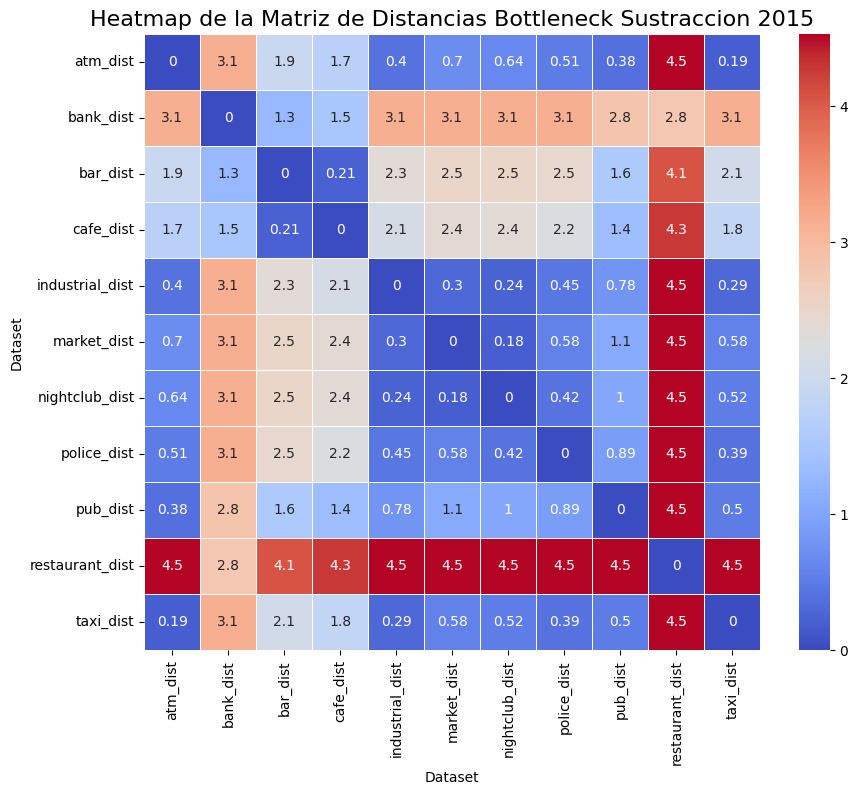

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Nueva matriz de distancias Bottleneck
dist_matrix_bottleneck = np.array([
    [0.        , 3.1343646 , 1.94698906, 1.73361969, 0.40044713, 0.69705129,
     0.63798213, 0.50587058, 0.38039851, 4.53146696, 0.19464427],
    [3.1343646 , 0.        , 1.27487659, 1.48824596, 3.1343646 , 3.1343646 ,
     3.1343646 , 3.1343646 , 2.84146714, 2.79420471, 3.1343646 ],
    [1.94698906, 1.27487659, 0.        , 0.21336937, 2.34743619, 2.49692631,
     2.49692631, 2.45285964, 1.56659055, 4.06908131, 2.06238055],
    [1.73361969, 1.48824596, 0.21336937, 0.        , 2.13406682, 2.39024162,
     2.37160182, 2.23949027, 1.35322118, 4.28245068, 1.84901118],
    [0.40044713, 3.1343646 , 2.34743619, 2.13406682, 0.        , 0.29660416,
     0.237535  , 0.44607508, 0.78084564, 4.53146696, 0.28505564],
    [0.69705129, 3.1343646 , 2.49692631, 2.39024162, 0.29660416, 0.        ,
     0.18205911, 0.58241969, 1.0774498 , 4.53146696, 0.58165979],
    [0.63798213, 3.1343646 , 2.49692631, 2.37160182, 0.237535  , 0.18205911,
     0.        , 0.41537237, 1.01838064, 4.53146696, 0.52259064],
    [0.50587058, 3.1343646 , 2.45285964, 2.23949027, 0.44607508, 0.58241969,
     0.41537237, 0.        , 0.88626909, 4.53146696, 0.39047909],
    [0.38039851, 2.84146714, 1.56659055, 1.35322118, 0.78084564, 1.0774498 ,
     1.01838064, 0.88626909, 0.        , 4.53146696, 0.49579   ],
    [4.53146696, 2.79420471, 4.06908131, 4.28245068, 4.53146696, 4.53146696,
     4.53146696, 4.53146696, 4.53146696, 0.        , 4.53146696],
    [0.19464427, 3.1343646 , 2.06238055, 1.84901118, 0.28505564, 0.58165979,
     0.52259064, 0.39047909, 0.49579   , 4.53146696, 0.        ]
])

# Nombres de los archivos CSV
csv_names = ['atm_dist', 'bank_dist', 'bar_dist', 'cafe_dist', 'industrial_dist',
        'market_dist', 'nightclub_dist', 'police_dist', 'pub_dist',
        'restaurant_dist', 'taxi_dist']

# Crear un heatmap utilizando seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(dist_matrix_bottleneck, annot=True, cmap="coolwarm", cbar=True, square=True, linewidths=.5,
            xticklabels=csv_names, yticklabels=csv_names)

# Añadir etiquetas a los ejes
plt.title('Heatmap de la Matriz de Distancias Bottleneck Sustraccion 2015', fontsize=16)
plt.xlabel('Dataset')
plt.ylabel('Dataset')

# Mostrar el heatmap
plt.show()
